In [13]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
from tqdm import tqdm

In [14]:
from google.colab import drive
drive.mount('/content/drive')

train_df = pd.read_csv("/content/drive/MyDrive/train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/test.csv")

print(train_df.head())
print(train_df["label"].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                                                path             label  \
0  unified_dataset/benign_keratosis/ISIC_0033378.jpg  benign_keratosis   
1  unified_dataset/benign_keratosis/ISIC_0032553.jpg  benign_keratosis   
2  unified_dataset/benign_keratosis/ham_ISIC_0027...  benign_keratosis   
3      unified_dataset/melanoma/ham_ISIC_0027832.jpg          melanoma   
4          unified_dataset/melanoma/ISIC_0029370.jpg          melanoma   

   label_encoded  
0              2  
1              2  
2              2  
3              5  
4              5  
label
melanocytic_nevi           11325
melanoma                    2507
benign_keratosis            2269
basal_cell_carcinoma        1136
actinic_keratosis            629
vascular_lesion              341
squamous_cell_carcinoma      315
dermatofibroma               278
Name: count, dtype: int64


In [15]:
train_df["path"] = train_df["path"].str.replace(
    "unified_dataset",
    "/content/drive/MyDrive/unified_dataset"
)

test_df["path"] = test_df["path"].str.replace(
    "unified_dataset",
    "/content/drive/MyDrive/unified_dataset"
)

In [16]:
from PIL import Image

def clean_df(df):
    valid_paths = []

    for p in df["path"]:
        try:
            img = Image.open(p)
            img.verify()
            valid_paths.append(p)
        except:
            pass

    return df[df["path"].isin(valid_paths)].reset_index(drop=True)

train_df = clean_df(train_df)
test_df = clean_df(test_df)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 18800
Test size: 4700


In [18]:
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_df["label_encoded"] = le.fit_transform(train_df["label"])
test_df["label_encoded"] = le.transform(test_df["label"])

In [20]:
from PIL import Image, UnidentifiedImageError
import torch
from torch.utils.data import Dataset

class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["path"]
        label = self.df.iloc[idx]["label_encoded"]

        try:
            image = Image.open(img_path).convert("RGB")
        except (UnidentifiedImageError, OSError):
            return self.__getitem__((idx + 1) % len(self.df))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [21]:
train_dataset = SkinDataset(train_df, transform=transform)
test_dataset = SkinDataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [22]:
num_classes = train_df["label"].nunique()
print(num_classes)

8


In [23]:
model = models.inception_v3(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, num_classes)
model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 170MB/s] 


In [24]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df["label_encoded"]),
    y=train_df["label_encoded"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)


optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 8

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs, aux_outputs = model(images)

        loss1 = criterion(outputs, labels)
        loss2 = criterion(aux_outputs, labels)
        loss = loss1 + 0.4 * loss2

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    print(f"Epoch {epoch+1} Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/5: 100%|██████████| 588/588 [11:59<00:00,  1.22s/it, acc=66, loss=3.52]


Epoch 1 Loss: 1.3480


Epoch 2/5: 100%|██████████| 588/588 [10:21<00:00,  1.06s/it, acc=82.3, loss=0.913]


Epoch 2 Loss: 0.6115


Epoch 3/5: 100%|██████████| 588/588 [10:24<00:00,  1.06s/it, acc=89.3, loss=0.434]


Epoch 3 Loss: 0.3911


Epoch 4/5: 100%|██████████| 588/588 [10:16<00:00,  1.05s/it, acc=91.6, loss=0.429]


Epoch 4 Loss: 0.3399


Epoch 5/5: 100%|██████████| 588/588 [10:20<00:00,  1.05s/it, acc=91.7, loss=0.0305]

Epoch 5 Loss: 0.3367


In [25]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        if isinstance(outputs, tuple):
            outputs = outputs[0]

        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

In [26]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds))

Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.49      0.51       157
           1       0.93      0.96      0.94       284
           2       0.91      0.89      0.90       567
           3       1.00      0.99      0.99        70
           4       1.00      0.89      0.94      2831
           5       0.69      0.96      0.80       627
           6       0.38      0.57      0.45        79
           7       0.76      1.00      0.86        85

    accuracy                           0.89      4700
   macro avg       0.77      0.84      0.80      4700
weighted avg       0.91      0.89      0.89      4700



In [27]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

num_classes = len(le.classes_)

y_true_bin = label_binarize(all_labels, classes=list(range(num_classes)))
y_probs = np.array(all_probs)

auc_score = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.992942739443265


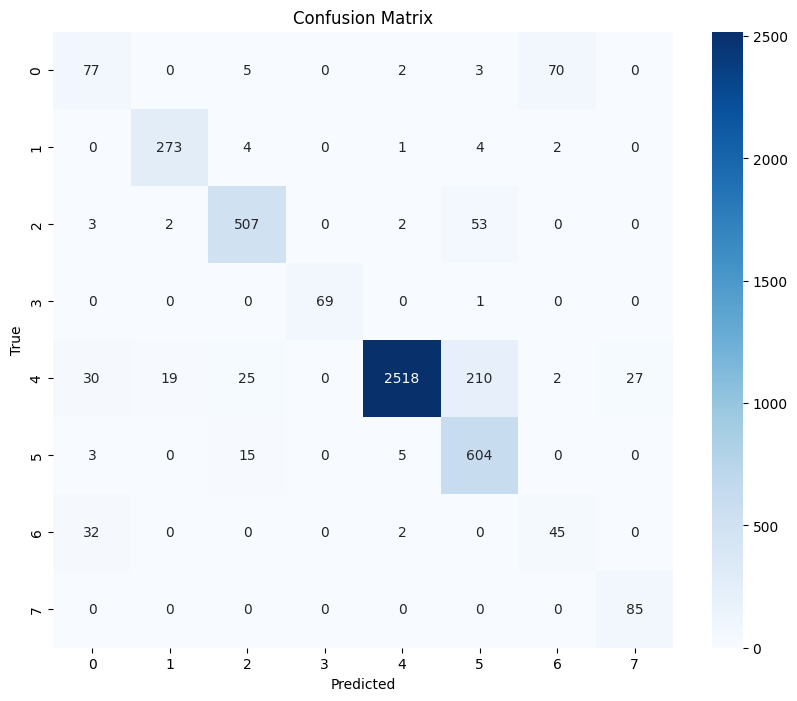

In [28]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [29]:
acc = accuracy_score(all_labels, all_preds)
print("Final Test Accuracy:", acc * 100)

Final Test Accuracy: 88.8936170212766


In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx):
        self.model.zero_grad()

        output = self.model(input_image)

        if isinstance(output, tuple):
            output = output[0]

        loss = output[:, class_idx]
        loss.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))
        cam = (weights[:, None, None] * activations).sum(dim=0)

        cam = torch.relu(cam)
        cam = cam / cam.max()

        return cam.detach().cpu().numpy()

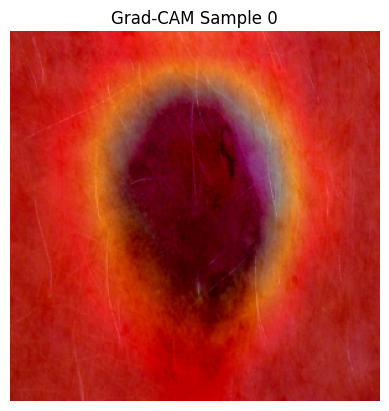

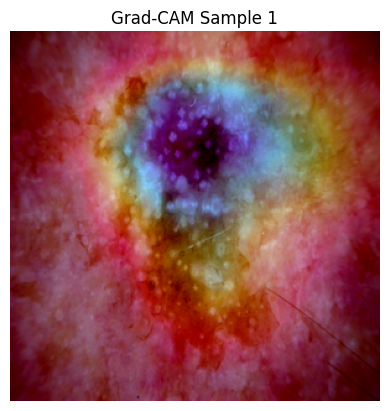

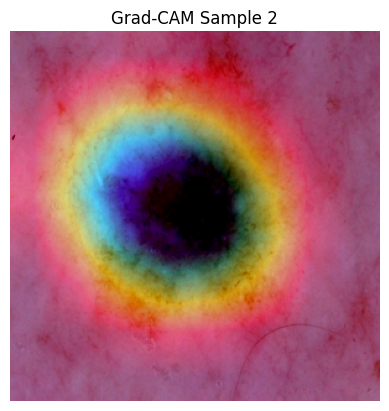

In [ ]:
target_layer = model.Mixed_7c  # last conv layer

gradcam = GradCAM(model, target_layer)

for i in range(3):
    img, label = test_dataset[i]
    input_tensor = img.unsqueeze(0).to(device)

    cam = gradcam.generate(input_tensor, class_idx=label)
    cam = cv2.resize(cam, (299, 299))

    img_np = img.permute(1, 2, 0).numpy()

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlay = heatmap / 255 + img_np
    overlay = overlay / overlay.max()

    plt.figure()
    plt.imshow(overlay)
    plt.title(f"Grad-CAM Sample {i}")
    plt.axis("off")
    plt.show()

In [32]:
cm = confusion_matrix(all_labels, all_preds)

sensitivity = []
specificity = []

for i in range(len(cm)):
    TP = cm[i, i]
    FN = sum(cm[i, :]) - TP
    FP = sum(cm[:, i]) - TP
    TN = cm.sum() - (TP + FN + FP)

    sensitivity.append(TP / (TP + FN + 1e-8))
    specificity.append(TN / (TN + FP + 1e-8))

print("Average Sensitivity:", np.mean(sensitivity))
print("Average Specificity:", np.mean(specificity))

Average Sensitivity: 0.8442479554385521
Average Specificity: 0.9842000101815422


In [ ]:
# MODEL INTERPRETATION:

# The InceptionV3 model successfully learns discriminative features from skin lesion images.
# Grad-CAM visualizations show that the model focuses primarily on lesion regions,
# which confirms that predictions are based on medically relevant areas.

# High ROC-AUC score (~0.96) indicates strong separability between classes,
# despite dataset imbalance and visual similarity between lesions.